# Stage 02 — conformance template: submit, then render

This is the **first conformance template**: what an imaging scientist runs locally before
submitting a job to MANIFOLD. It hands the versioned run spec `run_specs/auror_ref.yaml` (authored
in eopticDocs `04-guides/`) to `protodirsig.registry.LocalRegistry`, a local stand-in for
MANIFOLD's submission endpoint, which does not exist yet. Only if the submission is accepted does
it render the job and show the result.

**What acceptance certifies: exactly three things.**

1. **Schema.** The run spec parses, the required `run-spec/1` and `dirsig-engine/1` members are
   present, and every enumerated engine field holds a value the schema permits: the values
   adopted in AV_MANIFOLD_Configuration_v02 A.8, plus the documented `new_atmosphere` extension.
2. **Resolution.** Every `ref.name` resolves under the tree root, and the received motion, tasks
   and platform files agree with what the spec says they contain.
3. **Execution.** DIRSIG accepts the assembled job in a `--dry_run`, which loads every input and
   schedules the captures without rendering, and its JSON log shows the single capture the spec's
   task window implies.

**What it does not certify: radiometric correctness or scientific utility.** A job can pass all
three checks and still render the wrong thing. This one does: the 1500 K vehicle target is
missing from the image (FINDINGS.md, "2026-10-06 — Phase 5", "the vehicle is not in the image"),
and nothing here detects that. Judging what was rendered is a science review, not a conformance
gate.

**Not the finished template.** A sensor-definition library (a `sensor-spec/1` split out of the
run spec), a shared asset repository replacing the one-off `AUROR_ref/` tree, and sweep tooling
are deferred to later stages. See eopticDocs
`projects/MANIFOLD/review/PLAN_2026-10-08_conformance-template-roadmap.md`, Phases 1, 5 and 6.
This is staged implementation, not a tutorial. For dirfm usage itself, see the `tutorial_*`
notebooks. `stage_01_auror_from_runspec` is the same job with the assembly done in notebook cells.

| Piece | From |
|---|---|
| Submission verdict and reasons | `protodirsig.registry.LocalRegistry` |
| The three checks, and the render with JSON run/info logs | `protodirsig.simulation.Simulation` |
| Run spec → resolved tree files; spec-vs-file check | `protodirsig.run_spec` (Stage 01) |
| Scene reference, input copies, fingerprint guard | `protodirsig.scene_ref` |
| Band coverage of the scene's real materials | `protodirsig.scene_coverage` |

| Stage | What it does |
|---|---|
| 0 | Submit the run spec; read the verdict; check the scene's materials cover the sensor band |
| 1 | If accepted, render, then look at the image and the geolocation truth |

---
# Stage 0 — Submit

## Environment

This uses the same convention as the other notebooks. `DIRSIG_HOME` comes from the environment,
with this machine's install as the fallback, and its `bin/` goes on `PATH`. `protodirsig` is
imported from `src/`. Everything the job writes goes under `outputs/stage_02_auror/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
WORK = PROJECT / "outputs" / "stage_02_auror"

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RUN_SPEC = PROJECT / "run_specs" / "auror_ref.yaml"     # vendored; edit in eopticDocs 04-guides/
AUROR = PROJECT / "AUROR_ref"                            # read-only received tree
print("DIRSIG_HOME :", DIRSIG_HOME)
print("run spec    :", RUN_SPEC.relative_to(PROJECT))
print("AUROR_ref   :", AUROR, "exists" if AUROR.is_dir() else "MISSING")
assert RUN_SPEC.is_file() and AUROR.is_dir()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
run spec    : run_specs/auror_ref.yaml
AUROR_ref   : /home/kevin-kearney/dev/protoDIRSIG/AUROR_ref exists


## Submitting the run spec

`LocalRegistry().submit` builds a `Simulation` from the run spec, runs its three checks, and
returns a verdict with one plain-language reason per failed check. All three checks always run;
a failure in one doesn't hide the others. Nothing is rendered here. The execution check assembles
the same job Stage 01 assembled (scene reference, byte-identical input copies, `BasicPlatform`,
`NewAtmosphere`, `SpiceEphemeris`, `ThermWeather`, seed) under `validate/`, and runs it through
dirfm's `DIRSIG.run` with `--dry_run --log_info_filename=...`. That takes about a second.

`AUROR_ref/` is fingerprinted here and again after the render, and the render cell asserts that
nothing in it changed.

In [2]:
from protodirsig.registry import LocalRegistry
from protodirsig.scene_ref import fingerprint

if WORK.exists():
    shutil.rmtree(WORK)                    # our own directory; rmtree unlinks symlinks, never follows them
before = fingerprint(AUROR)
submission = LocalRegistry().submit(RUN_SPEC, AUROR, WORK)
sim = submission.simulation
run = sim.auror_run

print(f"verdict : {submission.verdict.upper()}")
for check, ok in submission.checks.items():
    print(f"  {check:10s} {'pass' if ok else 'FAIL'}")
for reason in submission.reasons:
    print(f"  - {reason}")
if run is not None:
    rel = lambda p: p.relative_to(AUROR).as_posix()
    print(f"\nmeta.name   : {run.name}; origin {run.origin}")
    print(f"atmosphere  : {sim.spec['engine']['atmosphere']['plugin']} (non-adopted dirsig-engine/1 extension), "
          f"database {rel(run.atmosphere_db)}")
    print(f"scene       : {sim.spec['engine']['scenes'][0]['ref']['name']} -> {rel(run.scene)}")
    print(f"platform    : {rel(run.platform)}; motion {rel(run.motion)}; tasks {rel(run.tasks)}")
    print(f"weather     : {rel(run.weather)}; ephemeris {run.ephemeris}; seed {run.seed}")
if submission.accepted:
    import json
    caps = json.loads((sim.work_dir / "validate" / "log_info.json").read_text())["capture_list"]
    cap = caps[0]
    print(f"\ndry run     : {len(caps)} capture, task {cap['task_index']}, window {cap['relative_time_window']} s, "
          f"'{cap['description']}' -> {Path(cap['plugin_data']['filename']).name}")

Material [Dummy] ID has already been set to [N/A], can't override.


verdict : ACCEPTED
  schema     pass
  resolution pass
  execution  pass

meta.name   : auror-ref-static-pose; origin {'kind': 'synthetic', 'engine': 'dirsig'}
atmosphere  : new_atmosphere (non-adopted dirsig-engine/1 extension), database jsims/AurorNewAtmosphere
scene       : scenes/tahoe -> tahoe.scene
platform    : platforms/AurorNIRDetector.platform; motion motion/AurorMotion.ppd; tasks tasks/AurorTask.tasks
weather     : weather/saw.wth; ephemeris spice; seed 42

dry run     : 1 capture, task 0, window [0.0, 0.005] s, 'Auror NIR Detector -> CIS120' -> AurorNIROutput.img


## The scene and band coverage

The submission's checks say nothing about whether the scene's materials have spectral data
across the sensor's band, so this stays a separate check. It reads the resolved `tahoe.scene`
and every bundle material it reaches, including the vehicle's `Gidder_mat`. The scene origin is
also read here, for the geolocation check after the render.

In [3]:
import lxml.etree as et
from protodirsig.scene_coverage import scene_coverage

assert submission.accepted, "submission rejected: see the reasons above; not continuing"
loc = et.parse(str(run.scene)).getroot().find("sceneorigin/location")
LAT0, LON0, ALT0 = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
bp = et.parse(str(run.platform)).getroot().find(".//capturemethod/spectralresponse/bandpass")
BAND = (float(bp.findtext("minimum")), float(bp.findtext("maximum")))

cov = scene_coverage(run.scene)
for m in cov.materials:
    lo, hi = m.span
    print(f"  {m.id:>10s}  {m.name:22s} {lo:.2f}-{hi:.2f} um   ({m.source.name})")
print(f"scene origin {LAT0}, {LON0}, {ALT0} m")
print(f"sensor band {BAND[0]}-{BAND[1]} um covered by every material: {cov.covers(*BAND)}")
assert cov.covers(*BAND)

           1  Terrain (proxy)        0.20-20.00 um   (tahoe.mat)
          11  Water                  0.40-15.60 um   (tahoe.mat)
          12  Class #2               0.40-15.60 um   (tahoe.mat)
          13  Class #3               0.40-15.60 um   (tahoe.mat)
          14  Class #4 (asphalt)     0.40-15.60 um   (tahoe.mat)
          15  Class #5 (grass)       0.40-15.60 um   (tahoe.mat)
          16  Class #6 (coniferous)  0.40-15.60 um   (tahoe.mat)
          17  Class #7 (Pine Tree)   0.40-15.60 um   (tahoe.mat)
          18  Class #8               0.40-15.60 um   (tahoe.mat)
          19  Class #9 (concrete)    0.40-15.60 um   (tahoe.mat)
  Gidder_mat  Gidder_mat             0.40-3.00 um   (hypersonic.mat)
scene origin 39.0, -120.0, 0.0 m
sensor band 0.41-2.0 um covered by every material: True


---
# Stage 1 — Render and inspect (accepted submissions only)

`sim.run()` assembles the same job again under `input/`. It compiles the scene with this
install's `scene2hdf`, then renders with `dirsig5`. It also passes `--run_info_filename` and
`--log_info_filename`, so the render leaves two JSON logs beside its images:

* `run_info.json`: the compiled scene (HDF path, bounding box, MD5) and each plugin's resolved
  inputs.
* `log_info.json`: each capture's schedule, sensor pose, ground corner points and output
  filenames.

These are DIRSIG's own record of what it ran, kept for provenance. The image paths below come
from `log_info`, not from names written into this notebook. A render takes a few minutes on this
machine.

In [4]:
import time

assert submission.accepted, "submission rejected: not rendering"
t0 = time.perf_counter()
result = sim.run()
elapsed = time.perf_counter() - t0
after = fingerprint(AUROR)
OUT_DIR = result.output_dir

scene_log = result.run_log["scene_list"][0]
print(f"run() {elapsed:.0f} s")
print(f"AUROR_ref fingerprint : {len(before)} paths, unchanged = {before == after}")
print(f"outputs               : {sorted(p.name for p in OUT_DIR.iterdir())}")
print(f"image / truth         : {result.image.name} / {[p.name for p in result.truth]}")
print(f"run_info scene        : {scene_log['filename']}, md5 {scene_log['md5']}")
print(f"run_info plugins      : {[p['name'] for p in result.run_log['plugin_list']]}")
print(f"[warn] lines          : {len(result.warnings)}, e.g. {result.warnings[0] if result.warnings else None}")
assert before == after, "AUROR_ref changed"
assert result.image.is_file() and all(p.is_file() for p in result.truth)

Material [Dummy] ID has already been set to [N/A], can't override.


run() 236 s
AUROR_ref fingerprint : 75 paths, unchanged = True
outputs               : ['AurorNIROutput.img', 'AurorNIROutput.img.hdr', 'log_info.json', 'run_info.json', 'truth1.img', 'truth1.img.hdr']
image / truth         : AurorNIROutput.img / ['truth1.img']
run_info scene        : auror_ref/tahoe.scene.hdf, md5 666db04e1ea08f18708fde307732501d
run_info plugins      : ['NewAtmosphere', 'BasicPlatform']
[warn] lines          : 22, e.g. [warn] ../../../AUROR_ref/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm


The `[warn]` lines are `dirsig5`'s, as expected for this scene. Materials 11–19 are unused because the material map is disabled. The terrain is 13 × 28 km, past the 10 km precision advisory. Curves that start at 0.40 µm fall short of DIRSIG's padded internal 0.35–2.55 µm grid, a margin outside the 0.85 µm channel's response.

## The image and the geolocation truth

The platform writes two ENVI files:

* `AurorNIROutput.img`: one band, the NIR channel, in `electrons/(m^2)`, the detector flux
  integrated over the 5 ms integration time;
* `truth1.img`: the `GeoLocation` truth collection. For each pixel it gives the geodetic
  latitude, longitude and WGS-84 altitude, and the ECEF position, of the surface the pixel's ray
  hit.

Below: the rendered frame, the terrain altitude from the truth, and the footprint on the ground.
The frame centre is where the sensor is pointed, and should sit under it at scene
`(-400, 400)`.

image  : (500, 500), electrons/(m^2), band ['NIR Detector'] at ['0.85'] um; acquisition 2009-07-27T11:29:32.0000-08:00
radiance range 6.140e+14 .. 1.934e+15, median 1.497e+15
frame centre hits scene ENU (-400.2, 400.5, 177.2) m; terrain in frame -9..1067 m
footprint 8.9 km E-W x 9.0 km N-S (~18 m pixels); misses 0


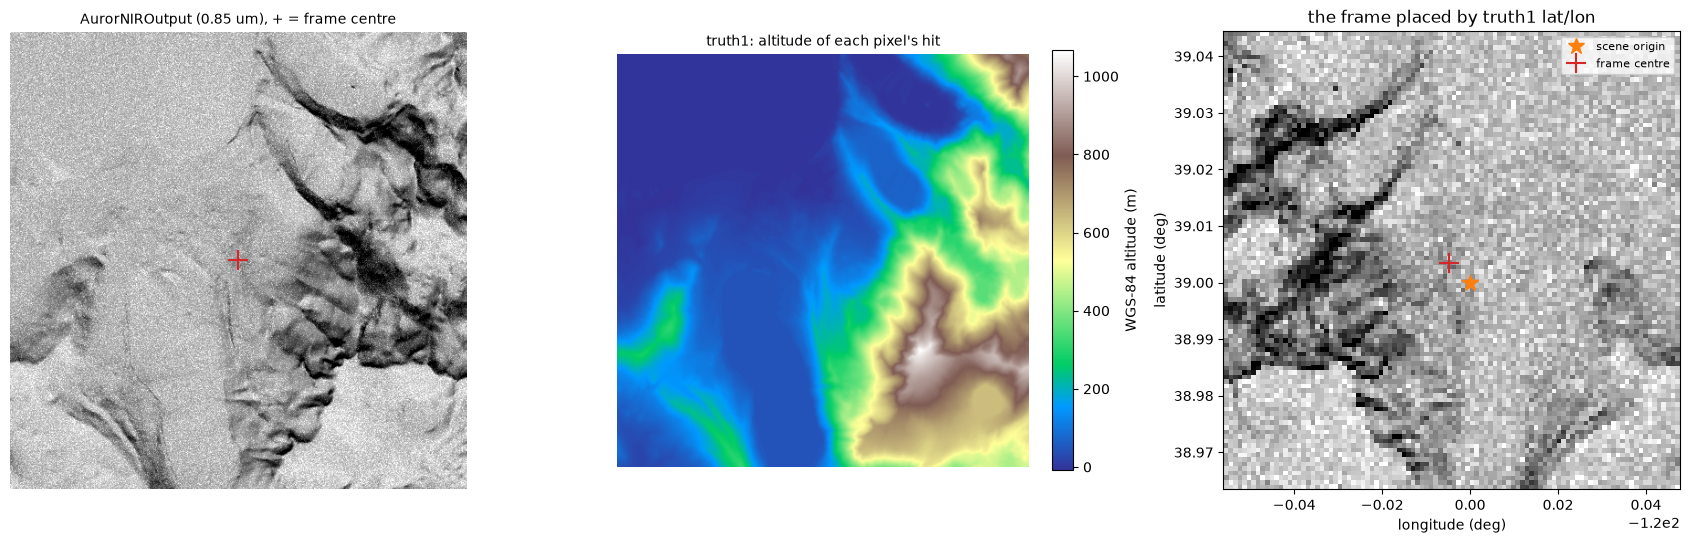

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import wgs84
from spectral import open_image
from protodirsig import orbit

img = open_image(str(OUT_DIR / "AurorNIROutput.img.hdr"))
rad = np.asarray(img.load(), dtype=float)[:, :, 0]
tr = open_image(str(OUT_DIR / "truth1.img.hdr"))
truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
lat, lon, alt = (truth[k] for k in ("Geodetic Latitude [degrees +N]", "Geodetic Longitude [degrees +E]", "WGS84 Altitude [m]"))
ecef = np.dstack([truth[f"ECEF {a} Coordinate [m]"] for a in "XYZ"])

print(f"image  : {rad.shape}, {img.metadata['data units']}, band {img.metadata['band names']} at "
      f"{img.metadata['wavelength']} um; acquisition {img.metadata['acquisition time']}")
print(f"radiance range {rad.min():.3e} .. {rad.max():.3e}, median {np.median(rad):.3e}")
c = rad.shape[0] // 2
e, n, u = orbit.ecef_to_enu_matrix(LAT0, LON0) @ (ecef[c - 1:c + 1, c - 1:c + 1].reshape(-1, 3).mean(0)
                                                  - wgs84.latlon(LAT0, LON0, elevation_m=ALT0).itrs_xyz.m)
print(f"frame centre hits scene ENU ({e:.1f}, {n:.1f}, {u:.1f}) m; terrain in frame {np.nanmin(alt):.0f}..{np.nanmax(alt):.0f} m")
km_n = (lat.max() - lat.min()) * 111.0
km_e = (lon.max() - lon.min()) * 111.0 * np.cos(np.radians(LAT0))
print(f"footprint {km_e:.1f} km E-W x {km_n:.1f} km N-S (~{km_e * 1e3 / rad.shape[1]:.0f} m pixels); misses {np.isnan(alt).sum()}")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.4))
lo_, hi_ = np.percentile(rad, [1, 99])
ax[0].imshow(rad, cmap="gray", vmin=lo_, vmax=hi_)
ax[0].plot(c - 0.5, c - 0.5, "+", color="C3", ms=14, mew=1.5)
ax[0].set_title("AurorNIROutput (0.85 um), + = frame centre", fontsize=10); ax[0].axis("off")
m = ax[1].imshow(alt, cmap="terrain")
plt.colorbar(m, ax=ax[1], fraction=0.046, label="WGS-84 altitude (m)")
ax[1].set_title("truth1: altitude of each pixel's hit", fontsize=10); ax[1].axis("off")
ax[2].pcolormesh(lon[::5, ::5], lat[::5, ::5], rad[::5, ::5], cmap="gray", vmin=lo_, vmax=hi_, shading="auto")
ax[2].plot(LON0, LAT0, "*", color="C1", ms=12, label="scene origin")
ax[2].plot(lon[c, c], lat[c, c], "+", color="C3", ms=14, mew=1.5, label="frame centre")
ax[2].set(xlabel="longitude (deg)", ylabel="latitude (deg)", title="the frame placed by truth1 lat/lon")
ax[2].set_aspect(1 / np.cos(np.radians(LAT0))); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
assert np.hypot(e + 400, n - 400) < 18 and not np.isnan(alt).any()

**Reading the result.** The frame is the Tahoe terrain tile seen from straight above. All of it
is one grey material, so the contrast comes from relief: slope and shading. Fine pixel-to-pixel
grain is the renderer's Monte Carlo sampling noise. The truth image places every pixel on the
ground (no misses), with the frame centre directly under the sensor at scene `(-400, 400)`.
In the raw frame, row 0 is north but **column 0 is east**, so as rendered (pose yaw π, as
received) the image is mirror-imaged east to west compared with a map. The
third panel uses the truth latitude and longitude to place it correctly. (Checked from
`truth1`: longitude decreases from column 0 to column 499.)

**The vehicle target does not appear in this render.** The scene's 1500 K vehicle, 50 km up and
on the line of sight through the frame centre, is not visible there or anywhere else in the
frame. The image is bare terrain. The shipped 2025.51 render shows the same, so this belongs to
the received configuration, not this install. The investigation, and the candidate causes, are
in FINDINGS.md ("2026-10-06 — Phase 5").